In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('../data/raw/data.csv')

In [4]:
print(df.info)
df.dtypes
# df.shape

<bound method DataFrame.info of               TransactionId         BatchId       AccountId  \
0       TransactionId_76871   BatchId_36123  AccountId_3957   
1       TransactionId_73770   BatchId_15642  AccountId_4841   
2       TransactionId_26203   BatchId_53941  AccountId_4229   
3         TransactionId_380  BatchId_102363   AccountId_648   
4       TransactionId_28195   BatchId_38780  AccountId_4841   
...                     ...             ...             ...   
95657   TransactionId_89881   BatchId_96668  AccountId_4841   
95658   TransactionId_91597    BatchId_3503  AccountId_3439   
95659   TransactionId_82501  BatchId_118602  AccountId_4841   
95660  TransactionId_136354   BatchId_70924  AccountId_1346   
95661   TransactionId_35670   BatchId_29317  AccountId_4841   

            SubscriptionId       CustomerId CurrencyCode  CountryCode  \
0       SubscriptionId_887  CustomerId_4406          UGX          256   
1      SubscriptionId_3829  CustomerId_4406          UGX         

TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object

In [5]:
print("Summary Statistics")
print(df.describe())

Summary Statistics
       CountryCode        Amount         Value  PricingStrategy   FraudResult
count      95662.0  9.566200e+04  9.566200e+04     95662.000000  95662.000000
mean         256.0  6.717846e+03  9.900584e+03         2.255974      0.002018
std            0.0  1.233068e+05  1.231221e+05         0.732924      0.044872
min          256.0 -1.000000e+06  2.000000e+00         0.000000      0.000000
25%          256.0 -5.000000e+01  2.750000e+02         2.000000      0.000000
50%          256.0  1.000000e+03  1.000000e+03         2.000000      0.000000
75%          256.0  2.800000e+03  5.000000e+03         2.000000      0.000000
max          256.0  9.880000e+06  9.880000e+06         4.000000      1.000000


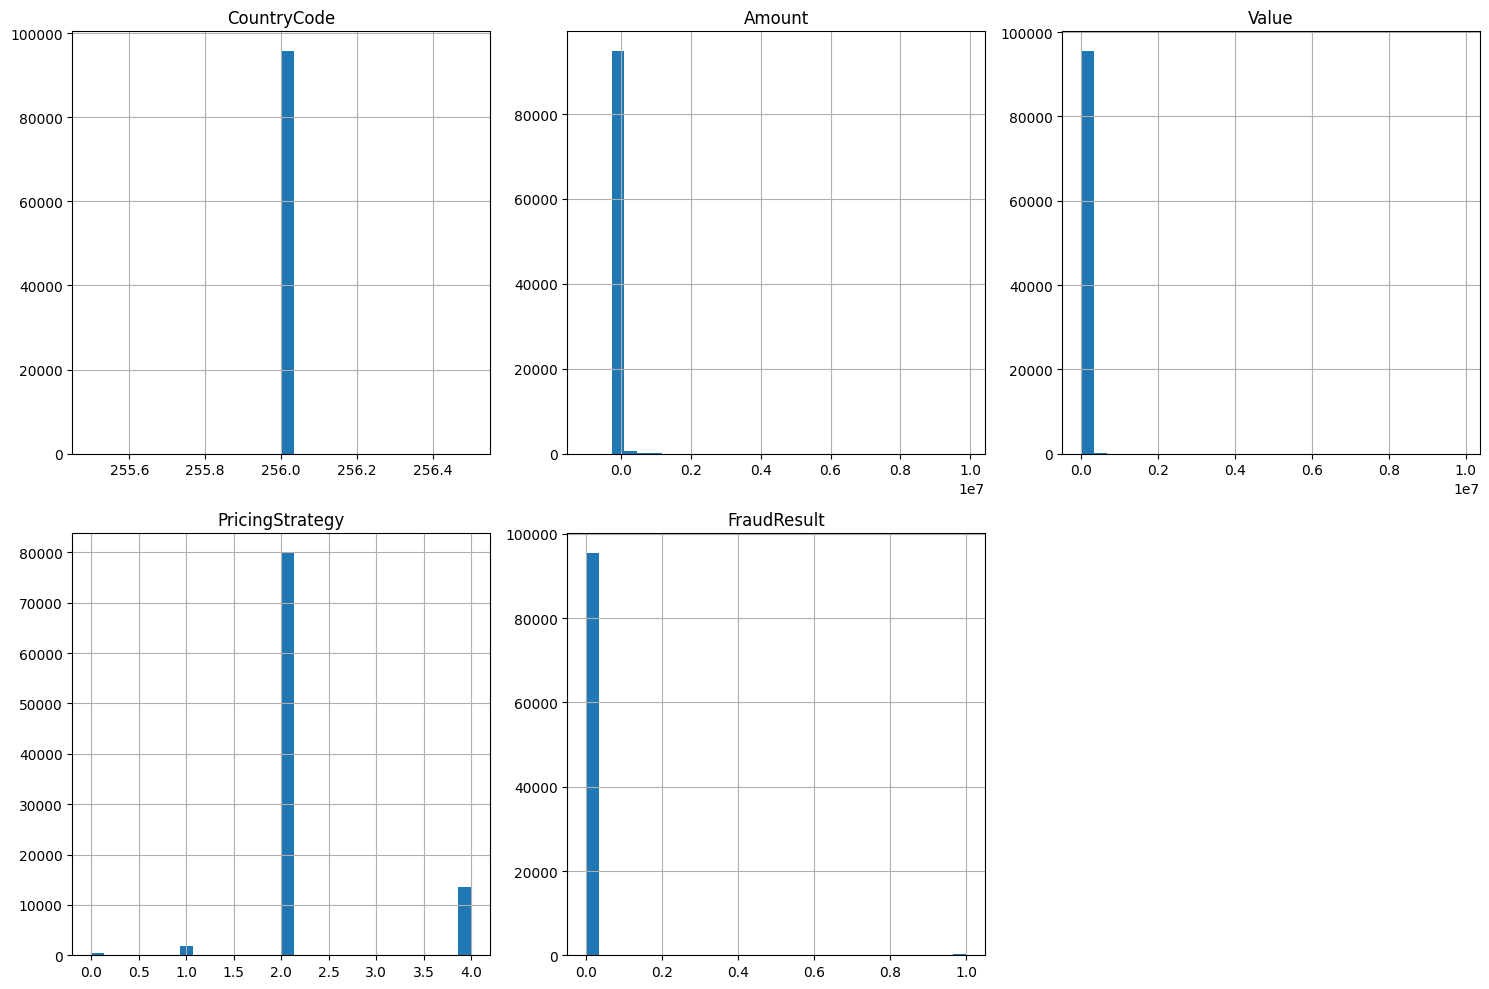

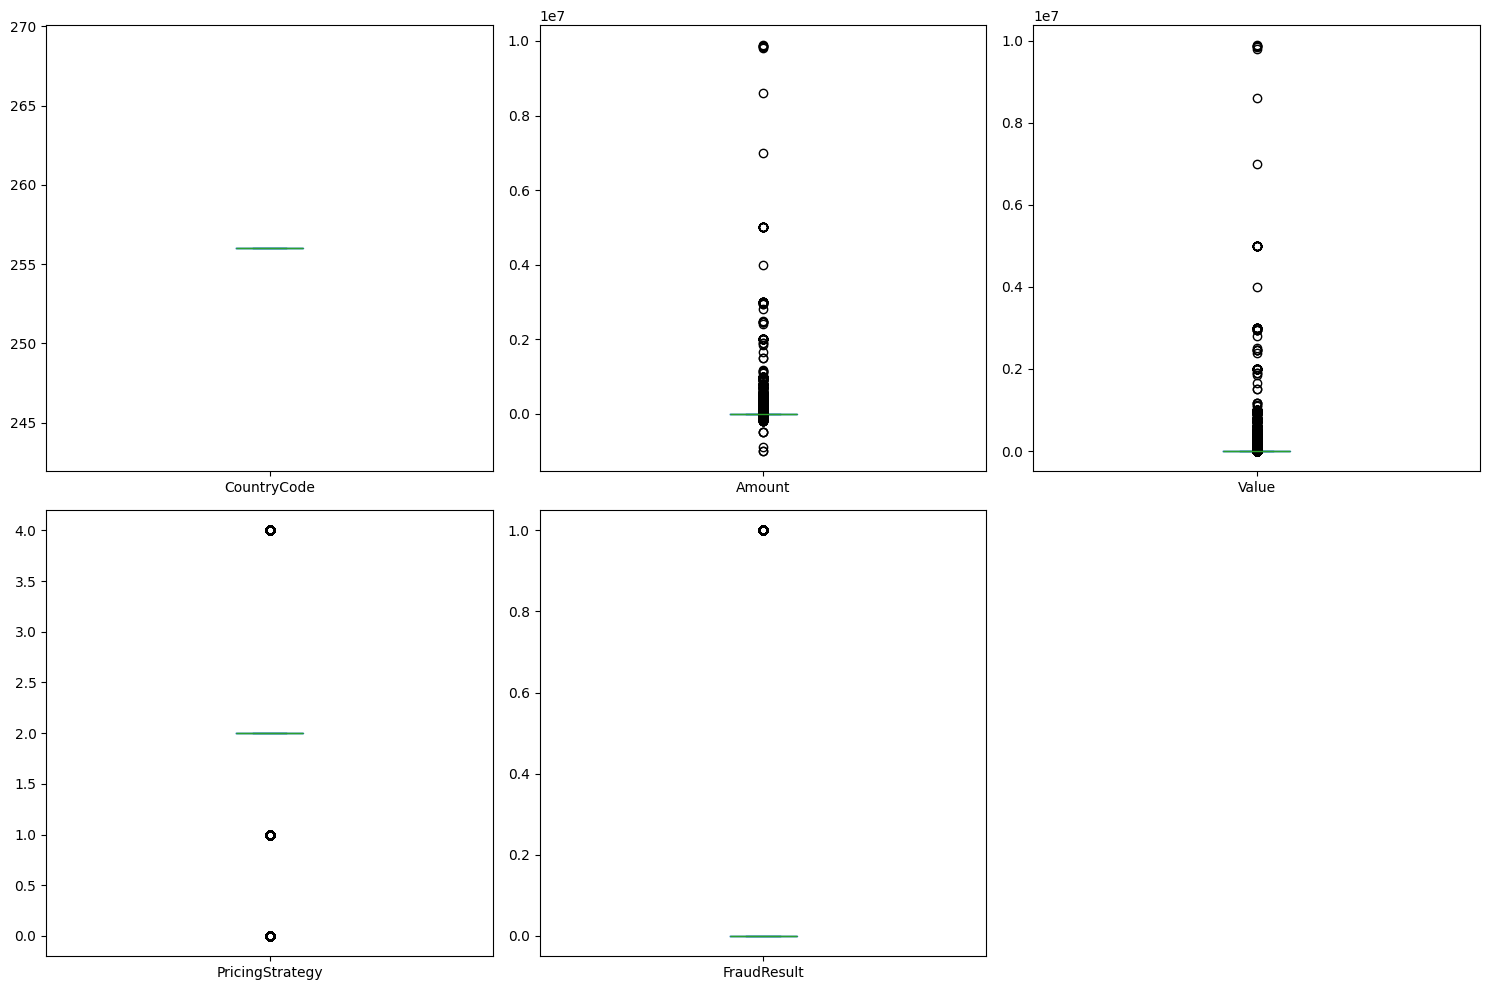

In [6]:
# Select numerical columns
numerical_cols = df.select_dtypes(include='number').columns

# Histograms for all numerical features
df[numerical_cols].hist(
    bins=30,
    figsize=(15, 10),
    layout=(len(numerical_cols) // 3 + 1, 3)
)

plt.tight_layout()
plt.show()
# identifying potential outliers

# Boxplots for all numerical features
df[numerical_cols].plot(
    kind='box',
    subplots=True,
    layout=(len(numerical_cols) // 3 + 1, 3),
    figsize=(15, 10),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

Skipping TransactionId (95662 unique values)
Skipping BatchId (94809 unique values)
Skipping AccountId (3633 unique values)
Skipping SubscriptionId (3627 unique values)
Skipping CustomerId (3742 unique values)


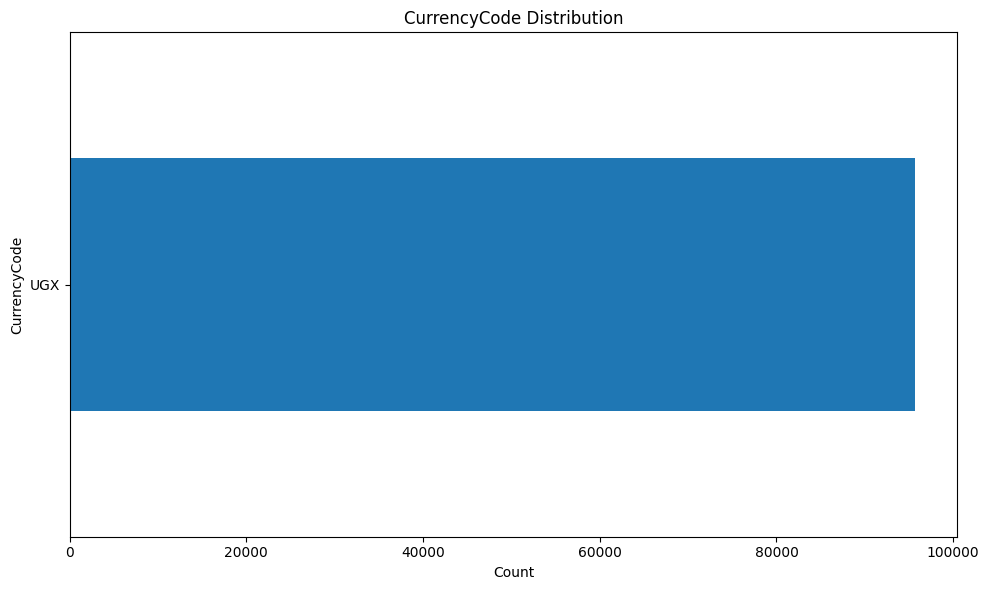

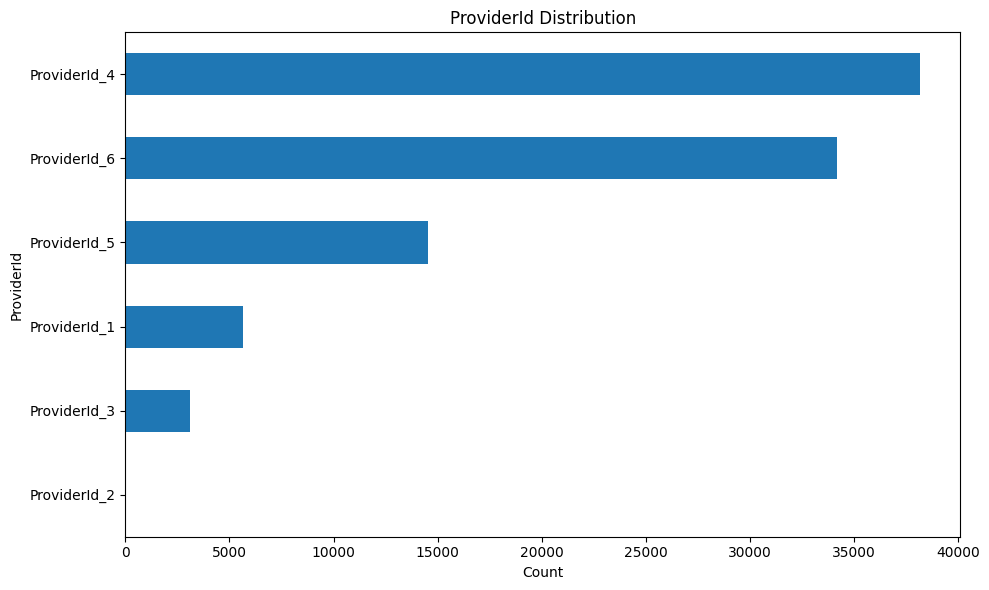

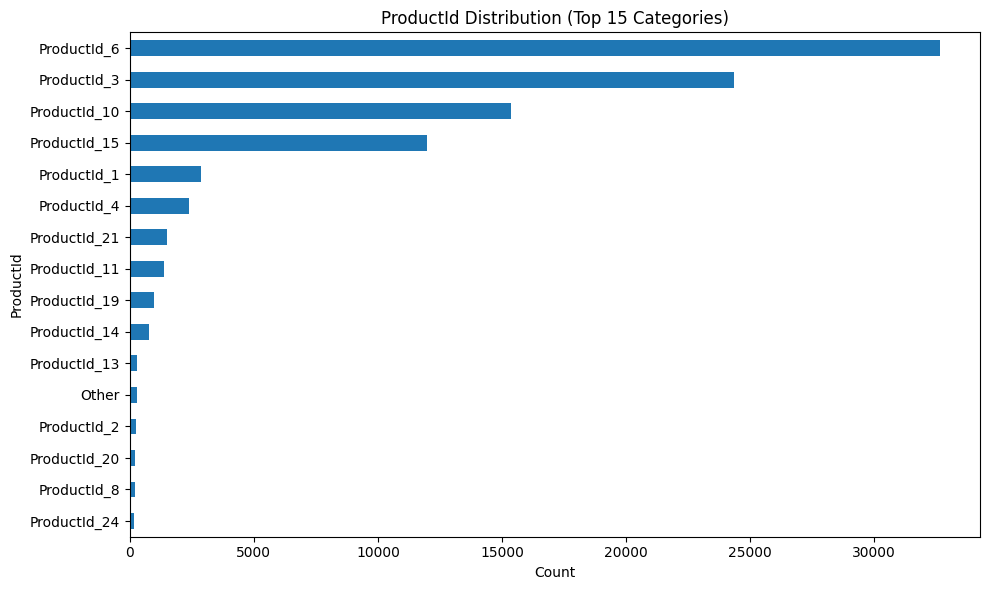

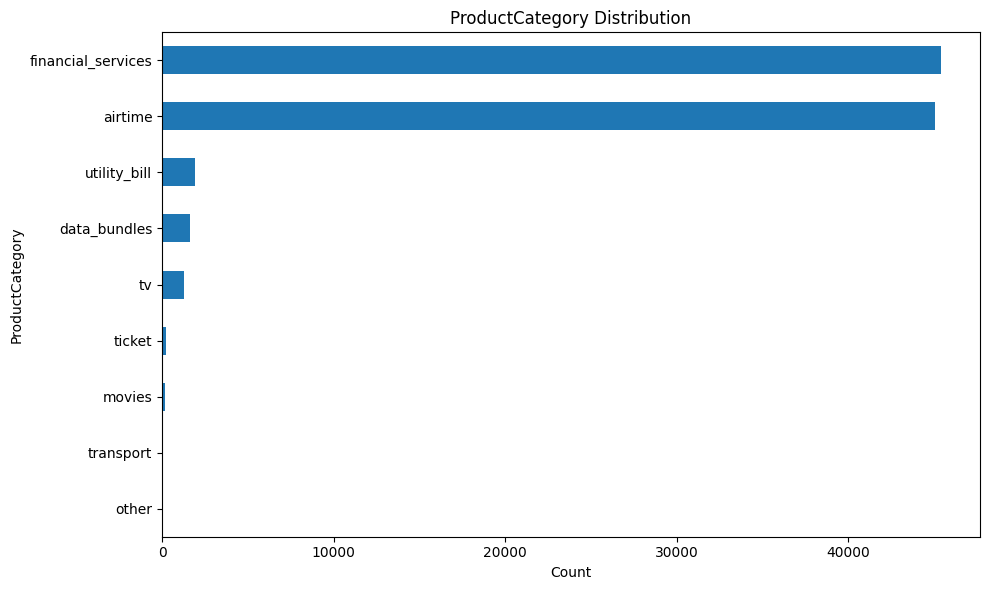

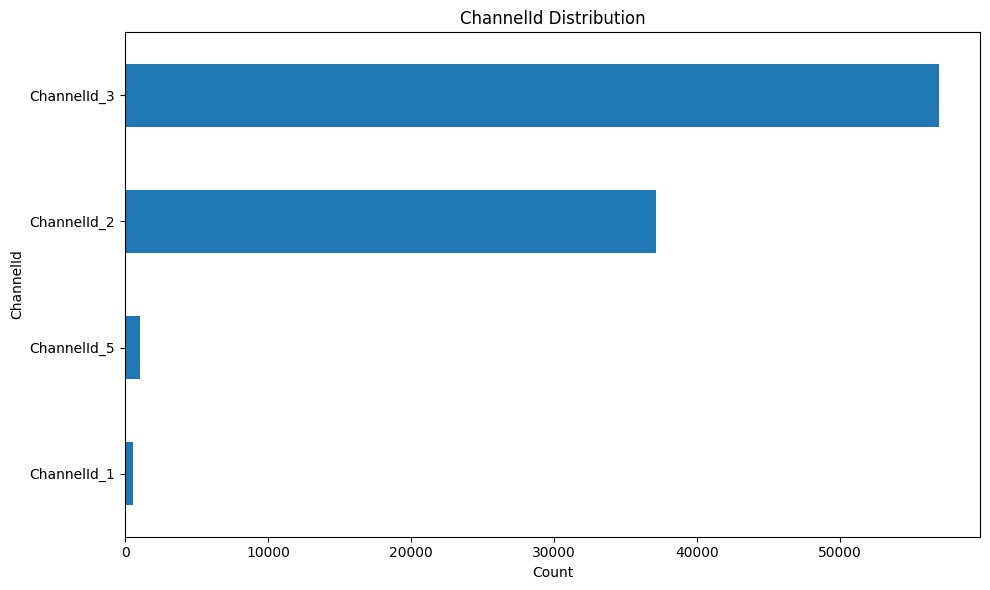

Skipping TransactionStartTime (94556 unique values)


In [11]:
# Select categorical columns
categorical_cols = df.select_dtypes(
    include=['object', 'category','string']
).columns

TOP_N = 15  # number of categories to display

for col in categorical_cols:
    
    vc = df[col].value_counts(dropna=False)

    # Skip columns with too many unique values
    if len(vc) > 100:
        print(f"Skipping {col} ({len(vc)} unique values)")
        continue

    # Keep top N and group the rest
    if len(vc) > TOP_N:
        top = vc.head(TOP_N)
        other_count = vc.iloc[TOP_N:].sum()
        vc_plot = pd.concat(
            [top, pd.Series({'Other': other_count})]
        )
    else:
        vc_plot = vc

    plt.figure(figsize=(10, 6))
    vc_plot.sort_values().plot(kind='barh')

    plt.title(
        f'{col} Distribution '
        f'(Top {TOP_N} Categories)' if len(vc) > TOP_N
        else f'{col} Distribution'
    )
    plt.xlabel('Count')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

In [8]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


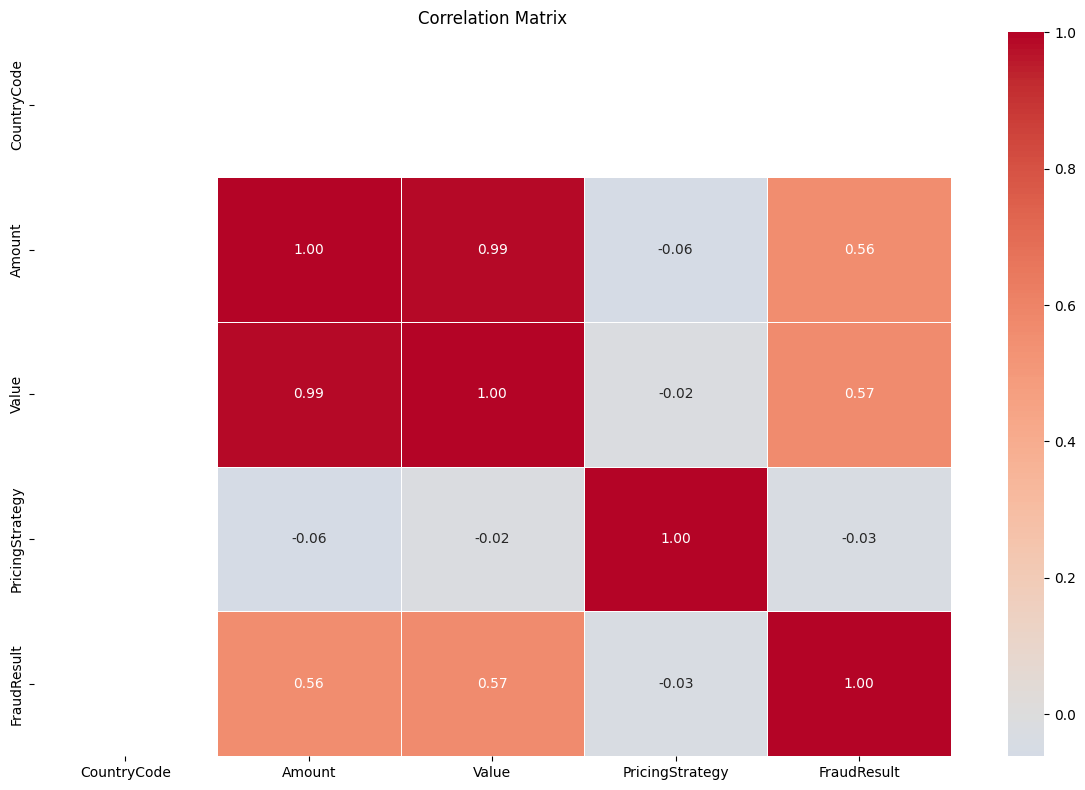

In [17]:
#correlation analysis
# Select numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numerical_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [15]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

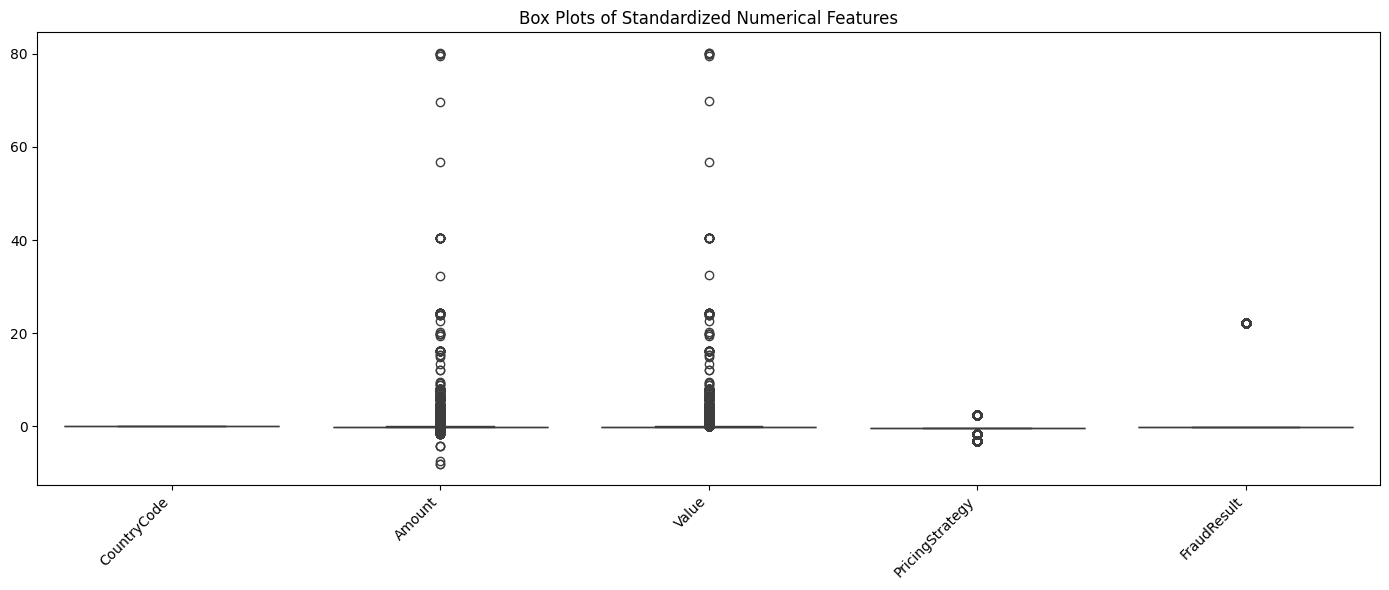

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

numerical_df = df.select_dtypes(include=['number'])

scaled_df = pd.DataFrame(
    StandardScaler().fit_transform(numerical_df),
    columns=numerical_df.columns
)

plt.figure(figsize=(14, 6))

sns.boxplot(data=scaled_df)

plt.title('Box Plots of Standardized Numerical Features')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Top Insights

Overview of the data
    - 95662 rows and 16 columns
    - Data types: 5 columns with Number and the rest 11 String
Summary Statistics 
    - The CountryCode feature has a constant value of 256 across all transactions, as indicated by a standard deviation of zero.
    - The Amount and Value variables exhibit substantial variability, with standard deviations of approximately 123,307 and 123,122 respectively.
    - The Amount feature contains negative values, with a minimum of -1,000,000.
    - The quartile analysis shows that 50% of transaction amounts fall between -50 and 2,800, while 50% of transaction values fall between 275 and 5,000.
    - The PricingStrategy variable has a mean of 2.26 and a median of 2, suggesting that pricing strategy category 2 is the most frequently used.
    - The FraudResult variable is highly imbalanced. The mean value of 0.002 indicates that only about 0.2% of transactions are labeled as fraudulent, while approximately 99.8% are legitimate.
Missing values
    - There are no missing values within the dataset.
